In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF, PCA
from sklearn.cluster import KMeans

plt.style.use('ggplot')

movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
print(f"Data loaded successfully!")

Data loaded successfully!


In [70]:
# Create User-Item matrix
# Rows are Users, Columns are Movies, Values are Ratings
R_df = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)
R = R_df.values

# For a better demo, only the top 500 most-rated movies are analyzed.
movie_counts = (R > 0).sum(axis=0)
top_movie_indices = movie_counts.argsort()[-500:]
R_subset = R[:, top_movie_indices]

top_movie_ids = R_df.columns[top_movie_indices]

print(f"Shape: {R_subset.shape} (Users x 500 Movies)")

Shape: (610, 500) (Users x 500 Movies)


In [71]:
# Perform Matrix Factorization with NMF for 6 latent features
n_components = 6
nmf = NMF(n_components=n_components, init='nndsvd', random_state=42, max_iter=500)
# W Matrix: User-Feature Matrix (Shape: Users x 6)
W = nmf.fit_transform(R_subset)
# H Matrix: Item-Feature Matrix (Shape: 6 x 500)
H = nmf.components_

print("NMF model training complete!")

NMF model training complete!


In [72]:
# Create a dictionary to look up movie titles by ID
id_to_title = movies.set_index('movieId')['title'].to_dict()

# Find the top 5 movies with the highest weights for each latent topic
for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[:-6:-1]
    top_ids = top_movie_ids[top_indices]
    print(f"\n【Feature {topic_idx}】:")
    for mid in top_ids:
        title = id_to_title.get(mid, "Unknown Movie")
        print(f"  - {title}")



【Feature 0】:
  - Shrek (2001)
  - Finding Nemo (2003)
  - Shrek 2 (2004)
  - Monsters, Inc. (2001)
  - Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)

【Feature 1】:
  - Forrest Gump (1994)
  - Apollo 13 (1995)
  - Fugitive, The (1993)
  - Braveheart (1995)
  - Shawshank Redemption, The (1994)

【Feature 2】:
  - Dark Knight, The (2008)
  - Up (2009)
  - Inception (2010)
  - WALL·E (2008)
  - Iron Man (2008)

【Feature 3】:
  - Fight Club (1999)
  - Pulp Fiction (1994)
  - Shawshank Redemption, The (1994)
  - Matrix, The (1999)
  - Usual Suspects, The (1995)

【Feature 4】:
  - Star Wars: Episode V - The Empire Strikes Back (1980)
  - Star Wars: Episode VI - Return of the Jedi (1983)
  - Star Wars: Episode IV - A New Hope (1977)
  - Terminator, The (1984)
  - Terminator 2: Judgment Day (1991)

【Feature 5】:
  - Casablanca (1942)
  - Fargo (1996)
  - Apocalypse Now (1979)
  - Rear Window (1954)
  - Psycho (1960)


In [73]:
# Set the number of user groups
n_clusters = 4
# Apply clustering to the 'W' matrix (User-Feature Matrix)
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
user_labels = kmeans.fit_predict(W)

unique, counts = np.unique(user_labels, return_counts=True)

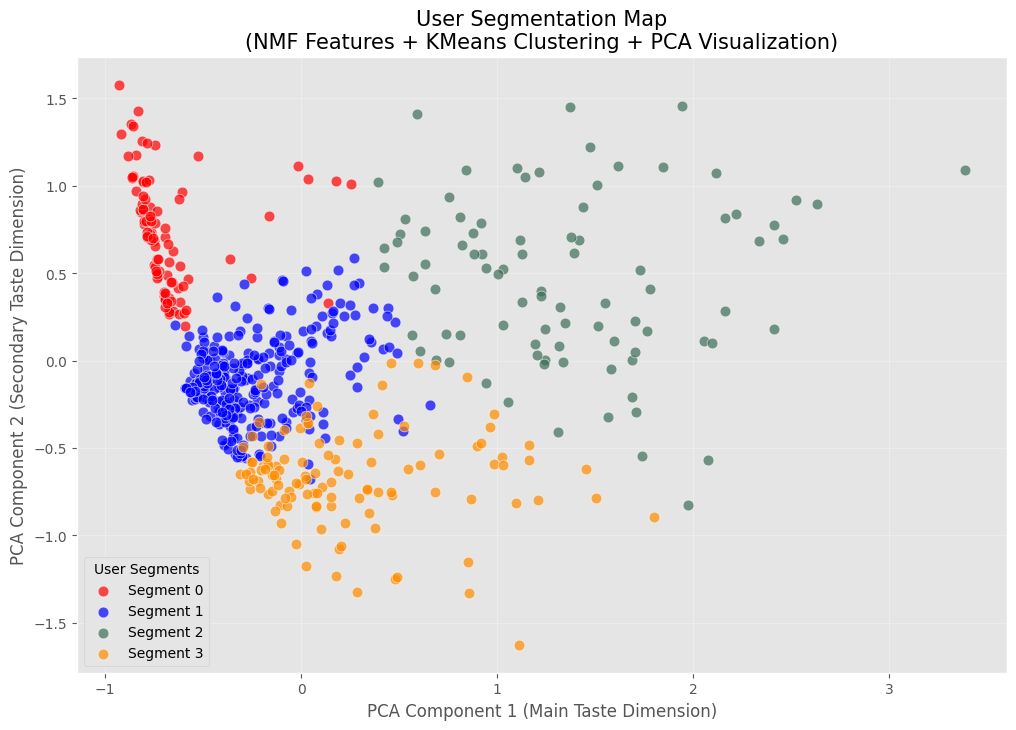

In [74]:
# Visualize user segments by projecting NMF features into 2D space via PCA
pca = PCA(n_components=2)
W_pca = pca.fit_transform(W)
plt.figure(figsize=(12, 8))
distinct_colors = ['#FF0000', '#0000FF', '#3c6e57', '#FF8C00']
n_clusters = 4
for i in range(n_clusters):
    mask = (user_labels == i)
    plt.scatter(W_pca[mask, 0],
                W_pca[mask, 1],
                c=distinct_colors[i],
                label=f'Segment {i}',
                alpha=0.7,
                s=60,
                edgecolors='white',
                linewidths=0.5)

plt.title(f'User Segmentation Map\n(NMF Features + KMeans Clustering + PCA Visualization)', fontsize=15)
plt.xlabel('PCA Component 1 (Main Taste Dimension)')
plt.ylabel('PCA Component 2 (Secondary Taste Dimension)')
plt.legend(title="User Segments", loc='best', frameon=True)
plt.grid(True, alpha=0.3)

plt.show()

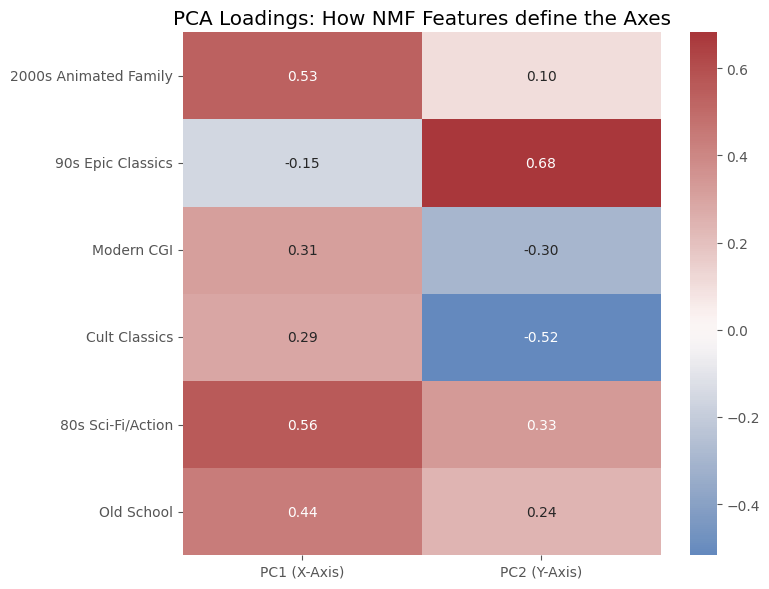

In [75]:
# Visualize how each NMF feature contributes to the PCA axes (PC1 and PC2)
feature_names = [
    "2000s Animated Family",
    "90s Epic Classics",
    "Modern CGI",
    "Cult Classics",
    "80s Sci-Fi/Action",
    "Old School"
]

plt.figure(figsize=(8, 6))
loadings_df = pd.DataFrame(pca.components_.T, columns=['PC1 (X-Axis)', 'PC2 (Y-Axis)'], index=feature_names)
sns.heatmap(loadings_df, annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('PCA Loadings: How NMF Features define the Axes')
plt.tight_layout()
plt.show()



In [76]:
# Purpose: Identify and display the primary and secondary features driving each user segment.

simple_summary = []
df_W = pd.DataFrame(W, columns=feature_names)
df_W['Cluster'] = user_labels
cluster_means = df_W.groupby('Cluster').mean()
# Extract the top 2 dominant features for each cluster
for i in range(n_clusters):
    top_features = cluster_means.loc[i].nlargest(2)

    cluster_info = {
        'Cluster ID': f"Cluster {i}",
        'Top Motivation': top_features.index[0],
        'Secondary Motivation': top_features.index[1]
    }
    simple_summary.append(cluster_info)

df_simple = pd.DataFrame(simple_summary)
try:
    display(df_simple)
except:
    print(df_simple.to_markdown(index=False))

,Cluster ID,Top Motivation,Secondary Motivation
0,Cluster 0,90s Epic Classics,80s Sci-Fi/Action
1,Cluster 1,80s Sci-Fi/Action,Cult Classics
2,Cluster 2,80s Sci-Fi/Action,2000s Animated Family
3,Cluster 3,Cult Classics,Modern CGI
